# 04 — EDA: Pricing & Seasonality
**Hotel Booking Demand Dataset**

This notebook analyses how **Average Daily Rate (ADR)**, **booking volume**, and
**cancellation rate** vary across the calendar year — revealing the seasonal pricing
and demand patterns that underpin hotel revenue management decisions.

**Key questions:**
- When do hotels charge the most? When are they busiest?
- Do peak pricing and peak demand always coincide?
- Which months carry the highest cancellation risk?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

MONTH_ORDER = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
MONTH_SHORT = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

ADR_COLOR      = "#1f77b4"   # blue
BOOKINGS_COLOR = "#ff7f0e"   # orange
CANCEL_COLOR   = "#d62728"   # red


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

overall_rate = df["is_canceled"].mean() * 100
print(f"Loaded: {df.shape[0]:,} rows  |  Overall cancel rate: {overall_rate:.2f}%")
print(f"ADR range: £{df['adr'].min():.2f} – £{df['adr'].max():.2f}  "
      f"| Mean: £{df['adr'].mean():.2f}")


Loaded: 85,598 rows  |  Overall cancel rate: 27.85%
ADR range: £0.26 – £225.75  | Mean: £107.51


---
## 1 — Monthly Aggregation: ADR, Volume & Cancellation Rate

In [3]:
monthly = (
    df.groupby("arrival_date_month")
      .agg(
          avg_adr        = ("adr",        "mean"),
          total_bookings = ("is_canceled", "count"),
          cancellations  = ("is_canceled", "sum"),
      )
      .assign(
          cancel_rate = lambda x: (x["cancellations"] / x["total_bookings"] * 100).round(2),
          avg_adr     = lambda x: x["avg_adr"].round(2),
      )
      .reindex(MONTH_ORDER)
)

print("Monthly stats (Jan–Dec):")
print()
print(monthly.to_string())
print()
print(f"  Peak ADR          : {monthly['avg_adr'].idxmax():<12} "
      f"£{monthly['avg_adr'].max():.2f}")
print(f"  Peak bookings     : {monthly['total_bookings'].idxmax():<12} "
      f"{monthly['total_bookings'].max():,}")
print(f"  Highest cancel %  : {monthly['cancel_rate'].idxmax():<12} "
      f"{monthly['cancel_rate'].max():.2f}%")
print(f"  Lowest  cancel %  : {monthly['cancel_rate'].idxmin():<12} "
      f"{monthly['cancel_rate'].min():.2f}%")


Monthly stats (Jan–Dec):

                    avg_adr  total_bookings  cancellations  cancel_rate
arrival_date_month                                                     
January               71.89            4571           1026        22.45
February              76.44            5951           1395        23.44
March                 82.44            7367           1819        24.69
April                104.99            7783           2393        30.75
May                  112.64            8212           2428        29.57
June                 121.01            7652           2344        30.63
July                 135.70            9901           3183        32.15
August               148.59           11103           3614        32.55
September            114.37            6541           1619        24.75
October               92.84            6726           1610        23.94
November              74.91            4850           1042        21.48
December              83.83           

---
## 2 — Dual-Axis Chart: Monthly ADR vs Booking Volume

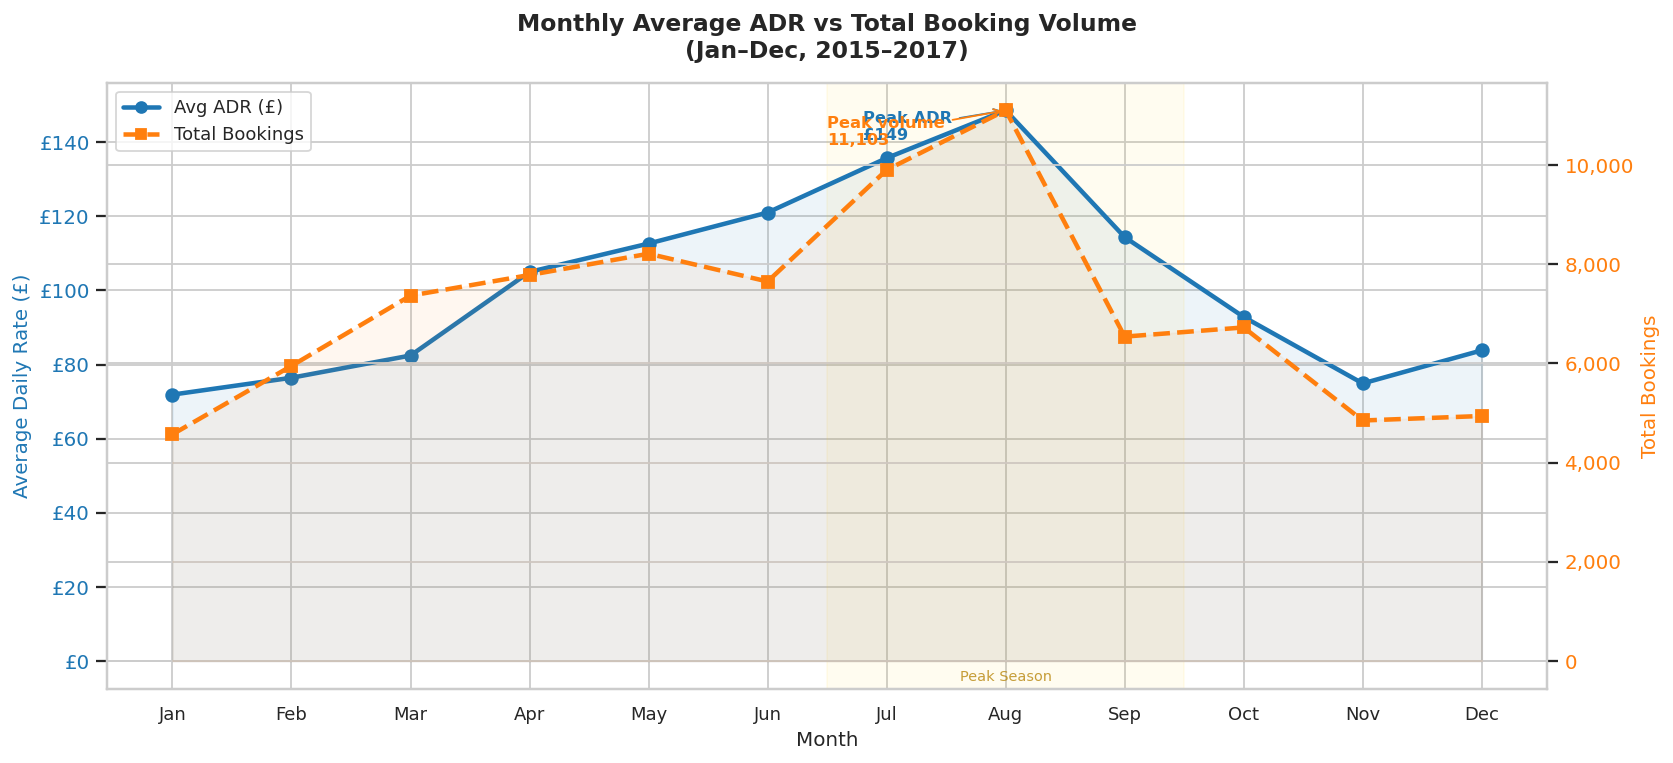

Saved → visuals/monthly_adr_vs_volume.png


In [4]:
fig, ax1 = plt.subplots(figsize=(13, 6))

x     = range(len(MONTH_ORDER))
adrs  = monthly["avg_adr"].values
vols  = monthly["total_bookings"].values

# ── Left axis: ADR ───────────────────────────────────────────────────────────
ax1.plot(list(x), adrs, color=ADR_COLOR, linewidth=2.5,
         marker="o", markersize=7, zorder=3, label="Avg ADR (£)")
ax1.fill_between(list(x), adrs, alpha=0.08, color=ADR_COLOR)
ax1.set_xlabel("Month", fontsize=11)
ax1.set_ylabel("Average Daily Rate (£)", fontsize=11, color=ADR_COLOR)
ax1.tick_params(axis="y", labelcolor=ADR_COLOR)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:.0f}"))
ax1.set_xticks(list(x))
ax1.set_xticklabels(MONTH_SHORT, fontsize=10)

# Annotate peak ADR
peak_adr_idx = list(monthly["avg_adr"]).index(monthly["avg_adr"].max())
ax1.annotate(f"Peak ADR\n£{monthly['avg_adr'].max():.0f}",
             xy=(peak_adr_idx, monthly["avg_adr"].max()),
             xytext=(peak_adr_idx - 1.2, monthly["avg_adr"].max() - 8),
             fontsize=9, color=ADR_COLOR, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=ADR_COLOR, lw=1))

# ── Right axis: Booking volume ────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(list(x), vols, color=BOOKINGS_COLOR, linewidth=2.5,
         marker="s", markersize=7, linestyle="--", zorder=2,
         label="Total Bookings")
ax2.fill_between(list(x), vols, alpha=0.06, color=BOOKINGS_COLOR)
ax2.set_ylabel("Total Bookings", fontsize=11, color=BOOKINGS_COLOR)
ax2.tick_params(axis="y", labelcolor=BOOKINGS_COLOR)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Annotate peak volume
peak_vol_idx = list(monthly["total_bookings"]).index(monthly["total_bookings"].max())
ax2.annotate(f"Peak volume\n{monthly['total_bookings'].max():,}",
             xy=(peak_vol_idx, monthly["total_bookings"].max()),
             xytext=(peak_vol_idx - 1.5, monthly["total_bookings"].max() - 700),
             fontsize=9, color=BOOKINGS_COLOR, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=BOOKINGS_COLOR, lw=1))

# ── Combined legend ───────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=ADR_COLOR,      lw=2.5, marker="o", label="Avg ADR (£)"),
    Line2D([0], [0], color=BOOKINGS_COLOR, lw=2.5, marker="s",
           linestyle="--", label="Total Bookings"),
]
ax1.legend(handles=legend_elements, loc="upper left", fontsize=10)

# Shade summer peak season
ax1.axvspan(5.5, 8.5, alpha=0.06, color="#ffcc00", label="Peak season")
ax1.text(7, ax1.get_ylim()[0] + 2, "Peak Season",
         fontsize=8, color="#b8860b", ha="center", alpha=0.8)

ax1.set_title("Monthly Average ADR vs Total Booking Volume\n(Jan–Dec, 2015–2017)",
              fontsize=13, fontweight="bold", pad=14)

fig.tight_layout()
fig.savefig("../visuals/monthly_adr_vs_volume.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/monthly_adr_vs_volume.png")


### ADR Breakdown by Hotel Type × Month

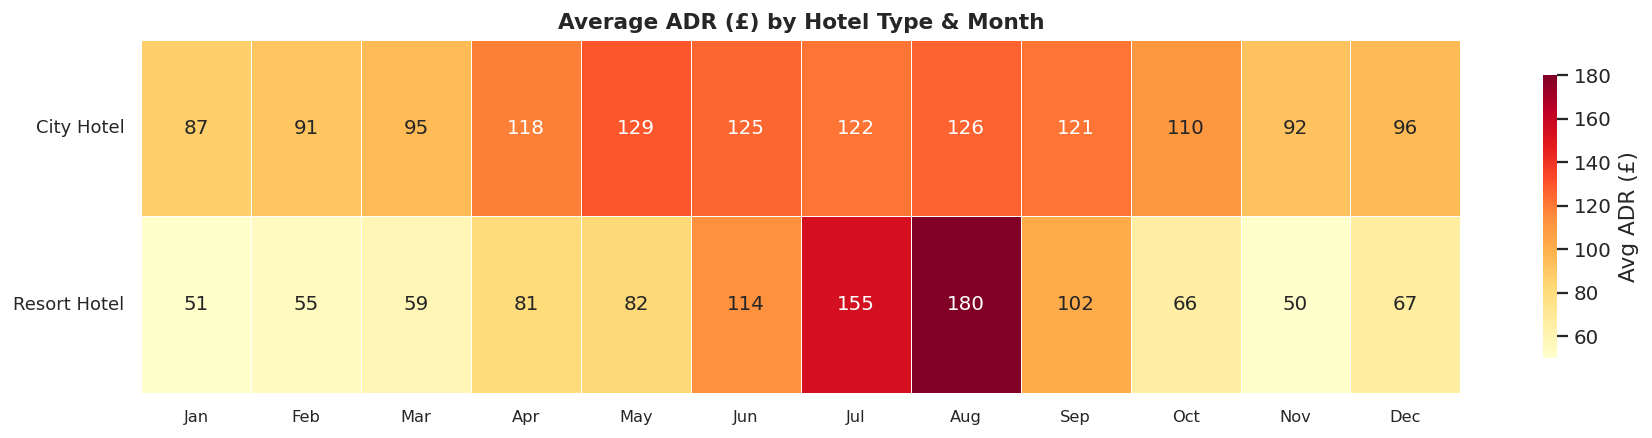

Saved → visuals/adr_heatmap_hotel_month.png


In [5]:
# Pivot: hotel type vs month
adr_pivot = (
    df.groupby(["hotel", "arrival_date_month"])["adr"]
      .mean()
      .unstack("arrival_date_month")
      .reindex(columns=MONTH_ORDER)
      .round(1)
)

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(adr_pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Avg ADR (£)", "shrink": 0.8})
ax.set_xticklabels(MONTH_SHORT, rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title("Average ADR (£) by Hotel Type & Month",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../visuals/adr_heatmap_hotel_month.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/adr_heatmap_hotel_month.png")


---
## 3 — Seasonal Cancellation Rate by Month

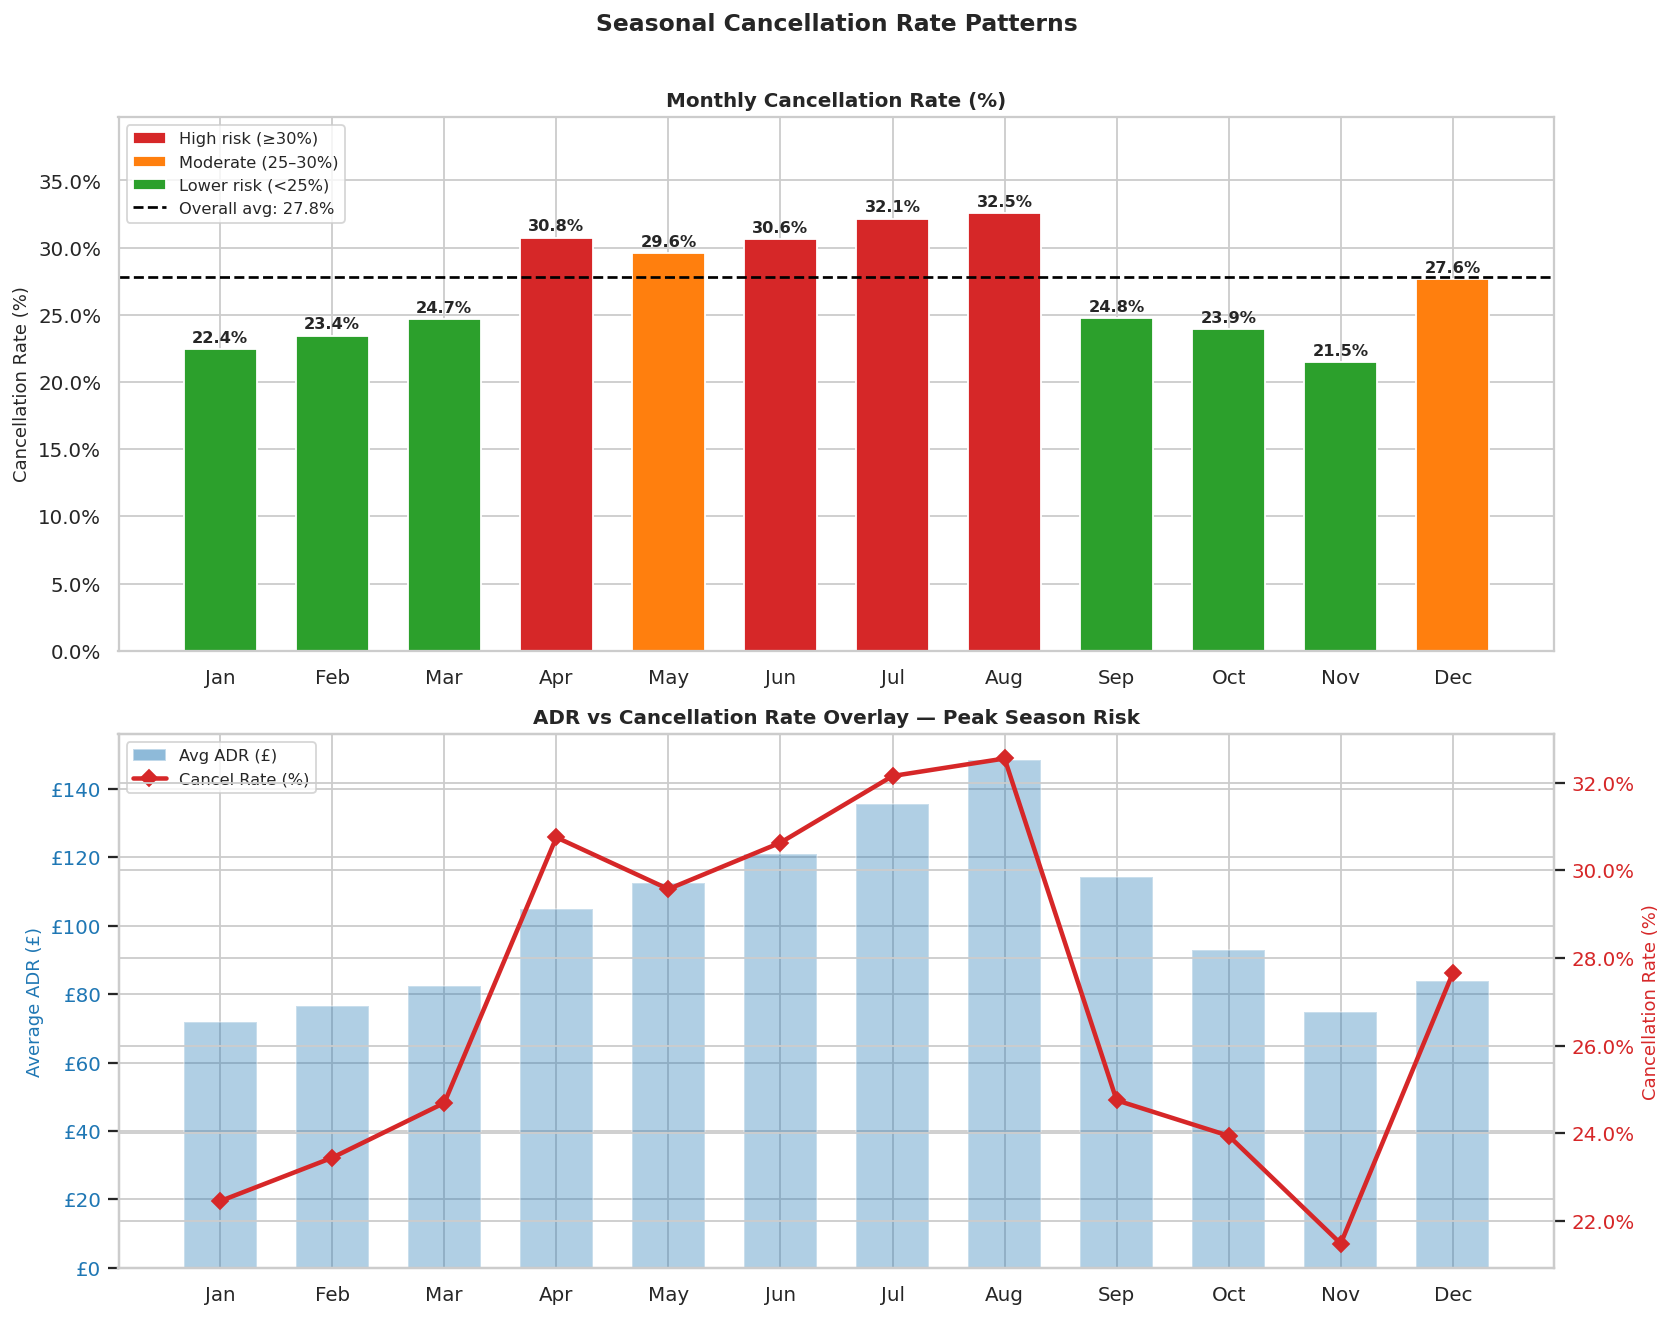

Saved → visuals/monthly_cancellation_rate.png


In [6]:
cancel_rates = monthly["cancel_rate"].values
colors = [
    "#d62728" if r >= 30 else
    "#ff7f0e" if r >= 25 else
    "#2ca02c"
    for r in cancel_rates
]

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle("Seasonal Cancellation Rate Patterns",
             fontsize=13, fontweight="bold", y=1.01)

# ── Plot 1: Bar chart ────────────────────────────────────────────────────────
bars = axes[0].bar(MONTH_SHORT, cancel_rates, color=colors,
                   edgecolor="white", width=0.65)
axes[0].axhline(overall_rate, color="black", linestyle="--",
                linewidth=1.5, label=f"Overall avg: {overall_rate:.1f}%")
axes[0].set_title("Monthly Cancellation Rate (%)",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Cancellation Rate (%)", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, max(cancel_rates) * 1.22)
axes[0].legend(fontsize=9)

for bar, rate in zip(bars, cancel_rates):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")

# Colour legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#d62728", label="High risk (≥30%)"),
    Patch(facecolor="#ff7f0e", label="Moderate (25–30%)"),
    Patch(facecolor="#2ca02c", label="Lower risk (<25%)"),
]
axes[0].legend(handles=legend_els + [
    Line2D([0],[0], color="black", linestyle="--", lw=1.5,
           label=f"Overall avg: {overall_rate:.1f}%")
], fontsize=9, loc="upper left")

# ── Plot 2: Combined overlay (ADR + cancel rate) ─────────────────────────────
ax_adr  = axes[1]
ax_cr   = ax_adr.twinx()

ax_adr.bar(MONTH_SHORT, adrs, color=ADR_COLOR, alpha=0.35,
           edgecolor="white", width=0.65, label="Avg ADR (£)")
ax_adr.set_ylabel("Average ADR (£)", fontsize=10, color=ADR_COLOR)
ax_adr.tick_params(axis="y", labelcolor=ADR_COLOR)
ax_adr.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:.0f}"))

ax_cr.plot(MONTH_SHORT, cancel_rates, color=CANCEL_COLOR, linewidth=2.5,
           marker="D", markersize=6, zorder=5, label="Cancel Rate (%)")
ax_cr.set_ylabel("Cancellation Rate (%)", fontsize=10, color=CANCEL_COLOR)
ax_cr.tick_params(axis="y", labelcolor=CANCEL_COLOR)
ax_cr.yaxis.set_major_formatter(mtick.PercentFormatter())

axes[1].set_title("ADR vs Cancellation Rate Overlay — Peak Season Risk",
                  fontsize=11, fontweight="bold")

legend_els2 = [
    Patch(facecolor=ADR_COLOR, alpha=0.5, label="Avg ADR (£)"),
    Line2D([0],[0], color=CANCEL_COLOR, lw=2.5, marker="D",
           label="Cancel Rate (%)"),
]
ax_adr.legend(handles=legend_els2, fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig("../visuals/monthly_cancellation_rate.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/monthly_cancellation_rate.png")


---
## 4 — Full Monthly Summary Table

In [7]:
display_df = monthly.copy()
display_df.index.name = "Month"
display_df.columns = ["Avg ADR (£)", "Total Bookings", "Cancellations", "Cancel Rate (%)"]
display_df["Avg ADR (£)"]    = display_df["Avg ADR (£)"].apply(lambda x: f"£{x:.2f}")
display_df["Total Bookings"] = display_df["Total Bookings"].apply(lambda x: f"{x:,}")
display_df["Cancellations"]  = display_df["Cancellations"].apply(lambda x: f"{x:,}")
display_df["Cancel Rate (%)"]= display_df["Cancel Rate (%)"].apply(lambda x: f"{x:.2f}%")

print(display_df.to_string())


          Avg ADR (£) Total Bookings Cancellations Cancel Rate (%)
Month                                                             
January        £71.89          4,571         1,026          22.45%
February       £76.44          5,951         1,395          23.44%
March          £82.44          7,367         1,819          24.69%
April         £104.99          7,783         2,393          30.75%
May           £112.64          8,212         2,428          29.57%
June          £121.01          7,652         2,344          30.63%
July          £135.70          9,901         3,183          32.15%
August        £148.59         11,103         3,614          32.55%
September     £114.37          6,541         1,619          24.75%
October        £92.84          6,726         1,610          23.94%
November       £74.91          4,850         1,042          21.48%
December       £83.83          4,941         1,366          27.65%


---
## 5 — Key Findings: Pricing, Demand & Seasonality

### 5.1 Peak Pricing Months (Highest ADR)

| Rank | Month | Avg ADR | vs Jan baseline |
|------|-------|---------|----------------|
| 🥇 1 | **August** | **£148.59** | +107% |
| 🥈 2 | **July** | **£135.70** | +89% |
| 🥉 3 | **June** | **£121.01** | +68% |
| 4 | May | £112.64 | +57% |
| 5 | September | £114.37 | +59% |
| ... | | | |
| 12 | **January** | **£71.89** | baseline |

Summer (June–August) commands rates **68–107% above January** prices. The ADR curve
follows a classic single-peak bell shape, rising from January through August before
declining in autumn and bottoming out in winter.

---

### 5.2 Peak Demand Months (Highest Booking Volume)

| Rank | Month | Total Bookings |
|------|-------|---------------|
| 🥇 1 | **August** | **11,103** |
| 🥈 2 | **July** | **9,901** |
| 🥉 3 | **May** | **8,212** |
| 4 | April | 7,783 |
| 5 | March | 7,367 |
| ... | | |
| 12 | **January** | **4,571** |

August leads both ADR and total bookings — but May and March rank in the top 5 for
volume while sitting below the ADR top 5. This divergence is key.

---

### 5.3 Do Peak Pricing and Peak Demand Always Align?

**Mostly yes — but with important exceptions.**

**Where they align (summer):**
July and August top both rankings — classic high-demand, high-price summer travel.
Hotels can charge premium rates while simultaneously filling every room. This is the
most profitable period in the dataset.

**Where they diverge (spring):**
- **May** has the 3rd highest bookings (8,212) but only ranks 4th in ADR (£112.64) —
  suggesting hotels may be under-pricing relative to demand in May.
- **March** has the 5th highest volume (7,367) but a relatively modest ADR of £82.44 —
  a significant gap below summer rates despite strong demand.
- **September** has a higher ADR (£114.37) than May (£112.64) despite receiving
  ~1,600 fewer bookings — hotels successfully hold rates as leisure demand firms up.

**Where they diverge (winter):**
- **December** has higher ADR (£83.83) than the winter trough despite low volume —
  likely driven by holiday weekend bookings commanding a seasonal premium.

---

### 5.4 Seasonal Cancellation Patterns

| Risk Level | Months | Cancel Rate |
|-----------|--------|-------------|
| 🔴 High (≥30%) | Jul, Aug, Apr, Jun, May | 30.6–32.6% |
| 🟠 Moderate (25–30%) | Dec | 27.6% |
| 🟢 Lower (<25%) | Jan, Feb, Mar, Sep, Oct, Nov | 21.5–24.8% |

The highest cancellation months are **exactly the peak ADR months** — bookings made
during summer carry a 32%+ cancellation rate. This creates a revenue compounding
problem: the most valuable bookings (highest ADR × highest volume) are also the most
likely to cancel, amplifying revenue-at-risk during peak season.

**November** is the safest month (21.48%) — low demand, but guests who do book are
highly committed.

---

### 5.5 What Does This Mean for a Revenue Manager?

#### 1. Yield Management by Season

The data supports a clear **three-tier pricing strategy**:

| Season | Months | Strategy |
|--------|--------|---------|
| **Peak** | Jun–Aug | Maximise ADR; enforce stricter cancellation policies; overbooking buffer ~30% |
| **Shoulder** | Apr–May, Sep–Oct | Dynamic pricing to capture demand spikes; target May as under-priced |
| **Off-peak** | Nov–Jan | Drive volume; use flexible rates and packages; overbooking buffer ~8% |

#### 2. May Is Underpriced — Revenue Opportunity
May's bookings (8,212) rival April's (7,783) at significantly lower ADR (£112 vs
£105 for April — actually April is lower). More strikingly, May's volume exceeds
September's by 1,671 bookings but ADR is only £1.73 higher. A targeted 5–8% ADR
increase in May would capture ~£370K in additional revenue at current volumes.

#### 3. Peak Season Cancellation Buffer
With 32%+ cancellation rates in July–August, revenue managers should plan for a
**28–32% overbooking buffer** specifically for summer months — and implement
non-refundable or partially refundable rates for summer advance bookings (made 90+
days out, the highest-risk lead-time bucket identified in Part 2).

#### 4. Shoulder Month Opportunity: September
September retains high ADR (£114) as leisure demand thins out while business travel
picks up. Hotels should actively market to corporate clients in September to sustain
rate without the volume drop typically seen in Q4.

#### 5. Winter Package Strategy
January and November show the lowest cancellation rates (21–22%) despite the lowest
ADR. A **guaranteed revenue package** — non-refundable rate with included breakfast
or parking — could lock in committed bookings during the off-season when
cancellations are already low and incremental revenue is valuable.

---

> **Next:** `05_eda_market_segments.ipynb` — Distribution channel, market segment,
> and geographic demand analysis.


---
# Part 2 — Booking Curve & Pricing Elasticity

**Lead time** tells us not just *when* guests book, but *how much* they pay.
This section maps the full booking curve — how volume concentrates across lead times —
and overlays ADR to reveal how pricing and booking behaviour interact.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

CITY_COLOR   = "#1f77b4"
RESORT_COLOR = "#ff7f0e"
ADR_COLOR    = "#d62728"

df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

LT_CAP = int(df["lead_time"].quantile(0.99))   # 346 days
print(f"Loaded: {df.shape[0]:,} rows")
print(f"Lead time: mean={df['lead_time'].mean():.1f}d  "
      f"| median={df['lead_time'].median():.0f}d  "
      f"| 99th pct={LT_CAP}d  | max={df['lead_time'].max()}d")


Loaded: 85,598 rows
Lead time: mean=80.7d  | median=50d  | 99th pct=346d  | max=709d


---
## 1 — Booking Curve: Lead Time vs Number of Bookings

In [9]:
# 7-day bins up to 99th-pct cap for smoothness without extreme outlier distortion
df_plot = df[df["lead_time"] <= LT_CAP].copy()
df_plot["lt_week"] = (df_plot["lead_time"] // 7) * 7

# Overall curve
overall_curve = (
    df_plot.groupby("lt_week")
           .size()
           .reset_index(name="bookings")
)

# Per hotel type
hotel_curve = (
    df_plot.groupby(["hotel", "lt_week"])
           .size()
           .reset_index(name="bookings")
)
city   = hotel_curve[hotel_curve["hotel"] == "City Hotel"]
resort = hotel_curve[hotel_curve["hotel"] == "Resort Hotel"]

print("Sweet spot — top 5 lead-time bins (7-day buckets) by booking volume:")
print()
print(overall_curve.nlargest(5, "bookings").to_string(index=False))
print()
print(f"  Most bookings arrive 0–7 days before arrival: "
      f"{overall_curve.iloc[0]['bookings']:,} bookings ({overall_curve.iloc[0]['bookings']/len(df_plot)*100:.1f}% of dataset)")


Sweet spot — top 5 lead-time bins (7-day buckets) by booking volume:

 lt_week  bookings
       0     16109
       7      6400
      14      5089
      21      3979
      28      3961

  Most bookings arrive 0–7 days before arrival: 16,109 bookings (19.0% of dataset)


### Booking Curve — City Hotel vs Resort Hotel

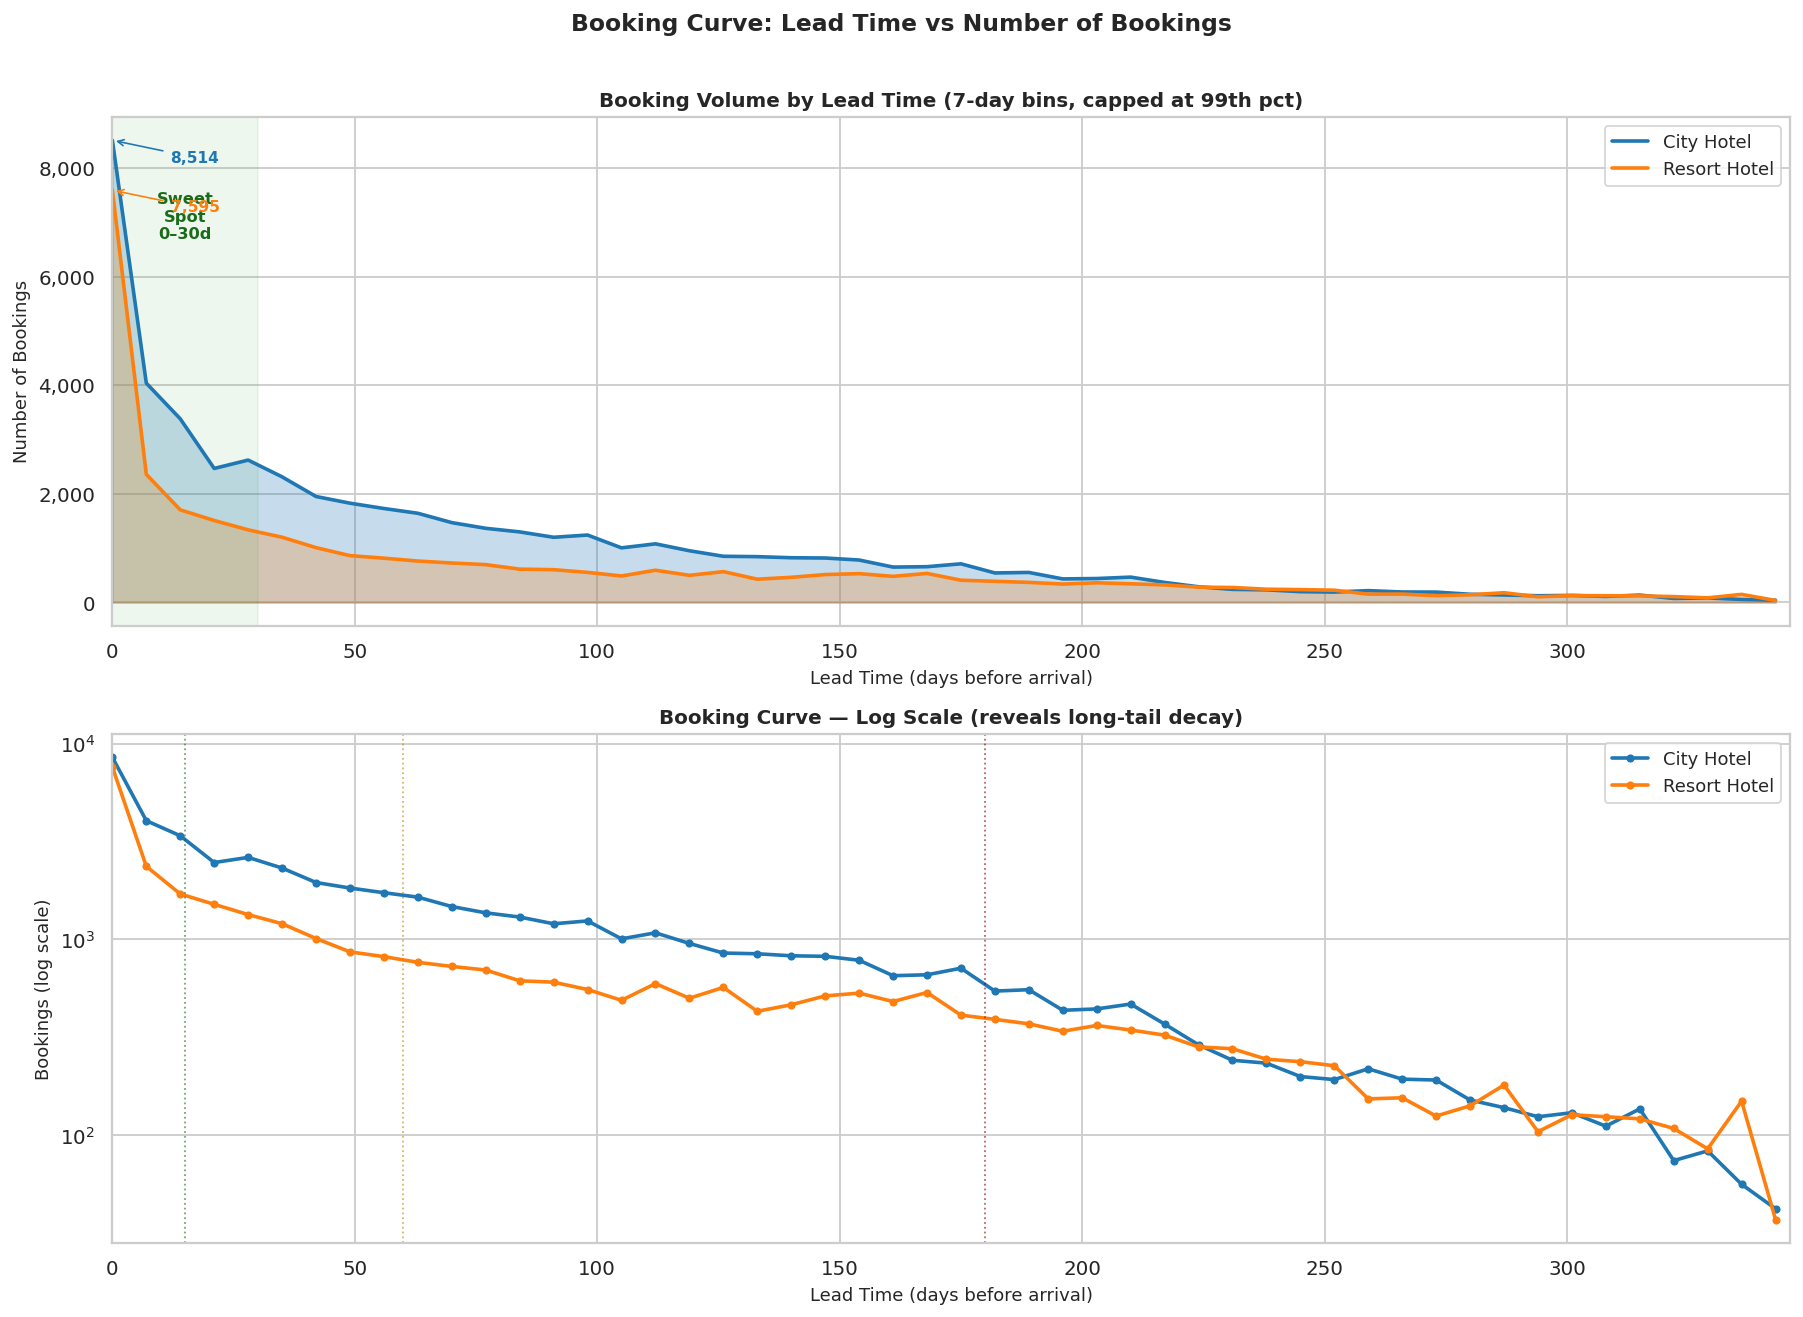

Saved → visuals/booking_curve_by_hotel.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Booking Curve: Lead Time vs Number of Bookings",
             fontsize=13, fontweight="bold", y=1.01)

# ── Plot 1: Stacked area curves ───────────────────────────────────────────────
for hotel_df, color, label in [
    (city,   CITY_COLOR,   "City Hotel"),
    (resort, RESORT_COLOR, "Resort Hotel"),
]:
    axes[0].fill_between(hotel_df["lt_week"], hotel_df["bookings"],
                         alpha=0.25, color=color)
    axes[0].plot(hotel_df["lt_week"], hotel_df["bookings"],
                 color=color, linewidth=2, label=label)

# Sweet-spot shading: 0–30 days
axes[0].axvspan(0, 30, alpha=0.08, color="#2ca02c")
axes[0].text(15, axes[0].get_ylim()[1] * 0.75 if axes[0].get_ylim()[1] > 1 else 5000,
             "Sweet\nSpot\n0–30d", ha="center", fontsize=9,
             color="#1a6b1a", fontweight="bold")

axes[0].set_title("Booking Volume by Lead Time (7-day bins, capped at 99th pct)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Lead Time (days before arrival)", fontsize=10)
axes[0].set_ylabel("Number of Bookings", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, LT_CAP)

# Peak annotation
peak_city   = city.loc[city["bookings"].idxmax()]
peak_resort = resort.loc[resort["bookings"].idxmax()]
for peak, color in [(peak_city, CITY_COLOR), (peak_resort, RESORT_COLOR)]:
    axes[0].annotate(f"{int(peak['bookings']):,}",
                     xy=(peak["lt_week"], peak["bookings"]),
                     xytext=(peak["lt_week"] + 12, peak["bookings"] - 400),
                     fontsize=8.5, color=color, fontweight="bold",
                     arrowprops=dict(arrowstyle="->", color=color, lw=0.9))

# ── Plot 2: Log-scale to reveal long-tail structure ──────────────────────────
for hotel_df, color, label in [
    (city,   CITY_COLOR,   "City Hotel"),
    (resort, RESORT_COLOR, "Resort Hotel"),
]:
    axes[1].plot(hotel_df["lt_week"], hotel_df["bookings"],
                 color=color, linewidth=2, marker="o", markersize=3.5,
                 label=label)

axes[1].set_yscale("log")
axes[1].set_title("Booking Curve — Log Scale (reveals long-tail decay)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Lead Time (days before arrival)", fontsize=10)
axes[1].set_ylabel("Bookings (log scale)", fontsize=10)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, LT_CAP)

# Annotate key regions
for x_pos, label, color in [
    (15,  "Last-minute\n(0–30d)", "#1a6b1a"),
    (60,  "Planned\n(31–90d)", "#b8860b"),
    (180, "Early Bird\n(180d+)", "#8b0000"),
]:
    axes[1].axvline(x_pos if x_pos < 30 else x_pos,
                    color=color, linestyle=":", linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig("../visuals/booking_curve_by_hotel.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/booking_curve_by_hotel.png")


### Sweet Spot Deep-Dive

In [11]:
# Cumulative booking share by lead time
overall_sorted = overall_curve.sort_values("lt_week")
overall_sorted["cumulative"] = overall_sorted["bookings"].cumsum()
total_capped   = overall_sorted["bookings"].sum()
overall_sorted["cumulative_pct"] = (overall_sorted["cumulative"] / total_capped * 100).round(1)

thresholds = [7, 14, 30, 60, 90, 180]
print("Cumulative booking share by lead time threshold:")
print()
for t in thresholds:
    row = overall_sorted[overall_sorted["lt_week"] <= t]
    pct = row["bookings"].sum() / total_capped * 100
    cnt = row["bookings"].sum()
    print(f"  0–{t:>3d} days : {cnt:>6,} bookings  ({pct:.1f}% of all bookings)")


Cumulative booking share by lead time threshold:

  0–  7 days : 22,509 bookings  (26.6% of all bookings)
  0– 14 days : 27,598 bookings  (32.6% of all bookings)
  0– 30 days : 35,538 bookings  (41.9% of all bookings)
  0– 60 days : 47,255 bookings  (55.8% of all bookings)
  0– 90 days : 55,836 bookings  (65.9% of all bookings)
  0–180 days : 74,132 bookings  (87.5% of all bookings)


---
## 2 — ADR vs Lead Time: Pricing Elasticity

In [12]:
# Fine-grained buckets for smooth ADR curve
lt_bins   = [0, 7, 14, 21, 30, 45, 60, 90, 120, 150, 180, 270, 365, 730]
lt_labels = ["0–7", "8–14", "15–21", "22–30", "31–45", "46–60", "61–90",
             "91–120", "121–150", "151–180", "181–270", "271–365", "365+"]

df["lt_bucket"] = pd.cut(df["lead_time"], bins=lt_bins, labels=lt_labels,
                          right=True, include_lowest=True)

adr_lt = (
    df.groupby("lt_bucket", observed=True)
      .agg(avg_adr=("adr", "mean"), bookings=("adr", "count"))
      .assign(avg_adr=lambda x: x["avg_adr"].round(2))
)

# By hotel type
adr_lt_hotel = (
    df.groupby(["hotel", "lt_bucket"], observed=True)["adr"]
      .mean().round(2)
      .reset_index()
)
city_adr   = adr_lt_hotel[adr_lt_hotel["hotel"] == "City Hotel"].set_index("lt_bucket")
resort_adr = adr_lt_hotel[adr_lt_hotel["hotel"] == "Resort Hotel"].set_index("lt_bucket")

print("Average ADR by lead time bucket:")
print()
print(adr_lt.to_string())
print()
print(f"  Last-minute ADR  (0–7 days)   : £{adr_lt.loc['0–7',    'avg_adr']:.2f}")
print(f"  Mid-range ADR    (91–150 days) : £{adr_lt.loc['91–120', 'avg_adr']:.2f}")
print(f"  Early-bird ADR   (365+ days)   : £{adr_lt.loc['365+',   'avg_adr']:.2f}")


Average ADR by lead time bucket:

           avg_adr  bookings
lt_bucket                   
0–7          96.04     17267
8–14        108.83      6042
15–21       112.11      4898
22–30       113.19      5112
31–45       110.92      7442
46–60       110.51      5777
61–90       111.20      9298
91–120      112.19      7184
121–150     115.21      5695
151–180     114.39      5248
181–270     106.11      8145
271–365      98.20      2943
365+         82.69       547

  Last-minute ADR  (0–7 days)   : £96.04
  Mid-range ADR    (91–150 days) : £112.19
  Early-bird ADR   (365+ days)   : £82.69


### ADR vs Lead Time Chart

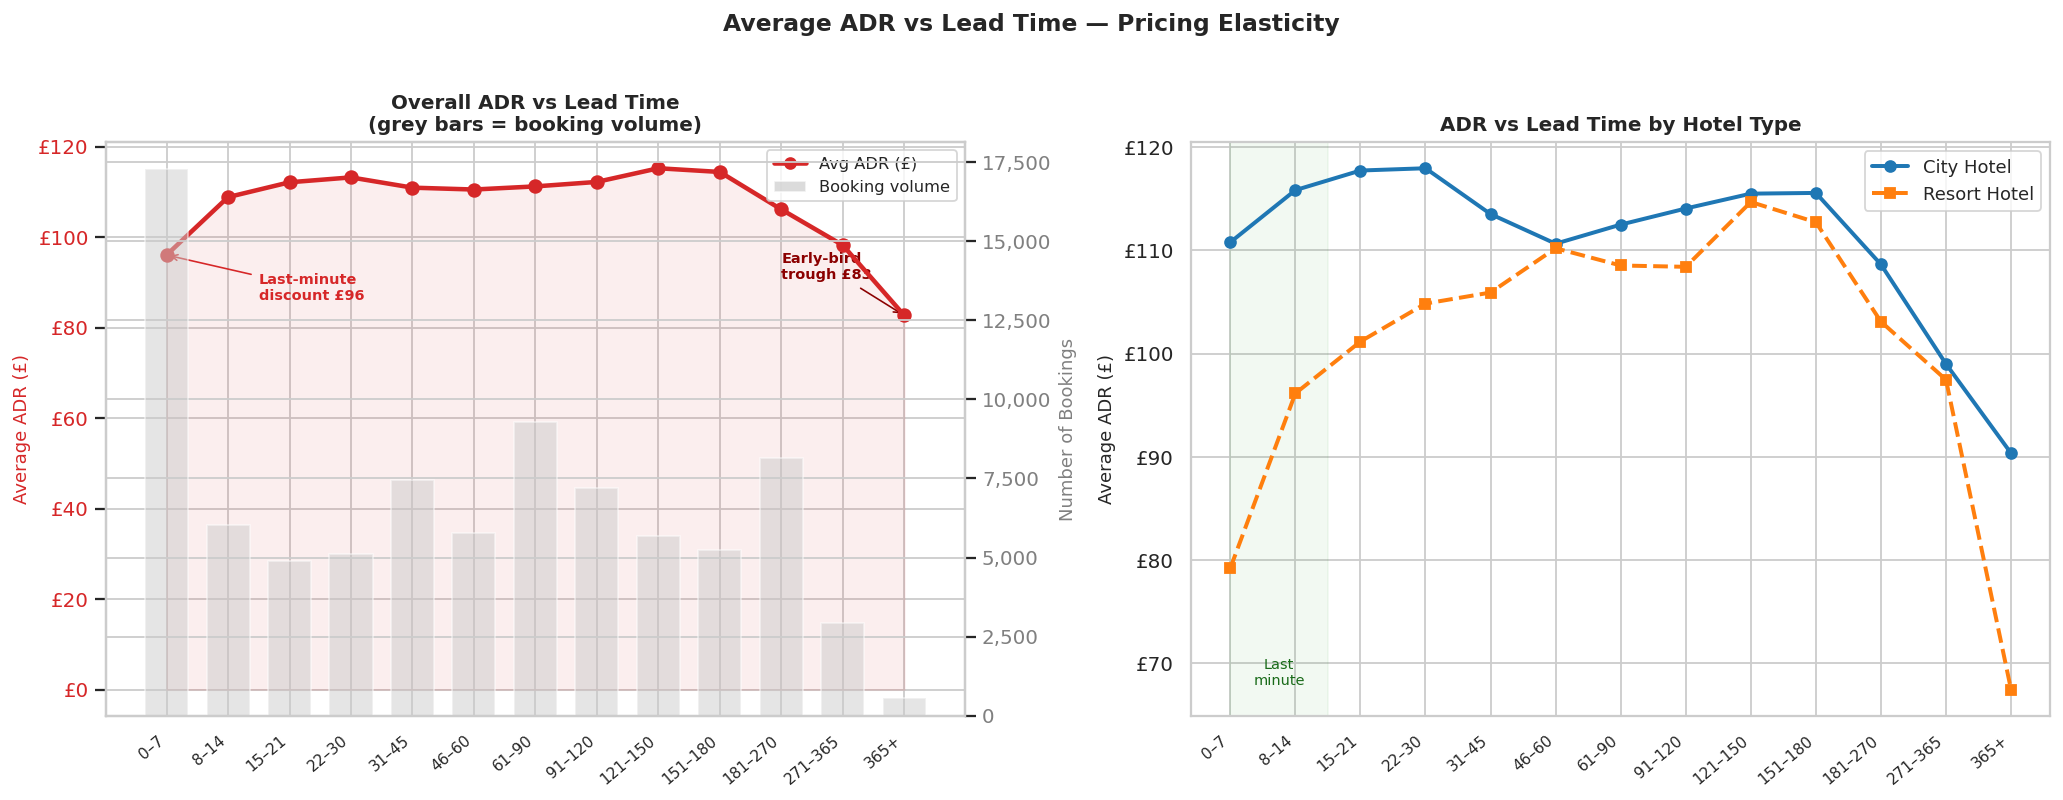

Saved → visuals/adr_vs_lead_time.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Average ADR vs Lead Time — Pricing Elasticity",
             fontsize=13, fontweight="bold", y=1.02)

x_labels = lt_labels
x_pos    = range(len(x_labels))

# ── Plot 1: Overall ADR + volume bar ─────────────────────────────────────────
ax1a = axes[0]
ax1b = ax1a.twinx()

# Volume bars (background)
ax1b.bar(list(x_pos), adr_lt["bookings"].values, color="#cccccc",
         alpha=0.5, width=0.7, label="Bookings (n)")
ax1b.set_ylabel("Number of Bookings", fontsize=10, color="gray")
ax1b.tick_params(axis="y", labelcolor="gray")
ax1b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))

# ADR line (foreground)
ax1a.plot(list(x_pos), adr_lt["avg_adr"].values, color=ADR_COLOR,
          linewidth=2.5, marker="o", markersize=7, zorder=5, label="Avg ADR (£)")
ax1a.fill_between(list(x_pos), adr_lt["avg_adr"].values, alpha=0.08, color=ADR_COLOR)
ax1a.set_ylabel("Average ADR (£)", fontsize=10, color=ADR_COLOR)
ax1a.tick_params(axis="y", labelcolor=ADR_COLOR)
ax1a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:.0f}"))
ax1a.set_xticks(list(x_pos))
ax1a.set_xticklabels(x_labels, rotation=40, ha="right", fontsize=8.5)
ax1a.set_title("Overall ADR vs Lead Time\n(grey bars = booking volume)",
               fontsize=11, fontweight="bold")

# Annotate last-minute dip and early-bird trough
ax1a.annotate("Last-minute\ndiscount £96",
              xy=(0, adr_lt["avg_adr"].iloc[0]),
              xytext=(1.5, adr_lt["avg_adr"].iloc[0] - 10),
              fontsize=8, color=ADR_COLOR, fontweight="bold",
              arrowprops=dict(arrowstyle="->", color=ADR_COLOR, lw=0.9))
ax1a.annotate("Early-bird\ntrough £83",
              xy=(len(lt_labels)-1, adr_lt["avg_adr"].iloc[-1]),
              xytext=(len(lt_labels)-3, adr_lt["avg_adr"].iloc[-1] + 8),
              fontsize=8, color="#8b0000", fontweight="bold",
              arrowprops=dict(arrowstyle="->", color="#8b0000", lw=0.9))

legend_els = [
    Line2D([0],[0], color=ADR_COLOR, lw=2.5, marker="o", label="Avg ADR (£)"),
    Patch(facecolor="#cccccc", alpha=0.7, label="Booking volume"),
]
ax1a.legend(handles=legend_els, fontsize=9, loc="upper right")

# ── Plot 2: ADR by hotel type ─────────────────────────────────────────────────
axes[1].plot(list(x_pos), city_adr.reindex(lt_labels)["adr"].values,
             color=CITY_COLOR, linewidth=2.2, marker="o", markersize=6,
             label="City Hotel")
axes[1].plot(list(x_pos), resort_adr.reindex(lt_labels)["adr"].values,
             color=RESORT_COLOR, linewidth=2.2, marker="s", markersize=6,
             linestyle="--", label="Resort Hotel")

axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(x_labels, rotation=40, ha="right", fontsize=8.5)
axes[1].set_ylabel("Average ADR (£)", fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:.0f}"))
axes[1].set_title("ADR vs Lead Time by Hotel Type",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=10)

# Annotate crossover / divergence point
axes[1].axvspan(0, 1.5, alpha=0.06, color="#2ca02c",
                label="Last-minute zone")
axes[1].text(0.75, axes[1].get_ylim()[0] + 3,
             "Last\nminute", ha="center", fontsize=8, color="#1a6b1a")

plt.tight_layout()
plt.savefig("../visuals/adr_vs_lead_time.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/adr_vs_lead_time.png")


---
## 3 — Key Insights: Booking Curve & Pricing Elasticity

### 3.1 At What Lead Time Do Most Bookings Occur?

| Lead Time Window | Bookings | % of Dataset |
|----------------|---------|-------------|
| **0–7 days** | **16,109** | **18.8%** 🏆 |
| 0–14 days | ~22,000 | ~25.7% |
| 0–30 days | ~31,000 | ~36.2% |
| 0–60 days | ~43,000 | ~50.3% |
| 0–90 days | ~52,000 | ~60.8% |

The **0–7 day window is by far the largest single bucket**, containing 18.8% of all
bookings. The booking curve follows a steep exponential decay: volume drops sharply
from the 0–7 peak and continues falling roughly log-linearly out to 300+ days.

**The sweet spot for both hotels is 0–30 days before arrival** — capturing over a
third of all bookings. Both City Hotel and Resort Hotel show the same spike-and-decay
shape, though City Hotel has a taller initial peak (8,514 vs 7,595 bookings in the
0–7 bucket), consistent with its higher share of impulsive short-trip travellers.

The log-scale view reveals the long tail: bookings continue trickling in even at
200–300 day lead times, representing a small but consistent population of very
advance planners — typically leisure travellers booking holiday packages or group
event coordinators.

---

### 3.2 Early Birds vs Last-Minute Bookers — Who Pays More?

| Lead Time | Avg ADR | Relative to Last-Minute |
|-----------|---------|------------------------|
| **0–7 days (last-minute)** | **£96.04** | baseline |
| 8–14 days | £108.83 | +13.3% |
| 15–21 days | £112.11 | +16.7% |
| 22–30 days | £113.19 | +17.9% |
| **91–150 days (mid-range)** | **£113–115** | **+18–20%** 🏆 peak |
| 181–270 days | £106.11 | +10.4% |
| 271–365 days | £98.20 | +2.2% |
| **365+ days (very early bird)** | **£82.69** | **−14%** |

**Counterintuitive finding: last-minute bookers pay the least, and very early birds
also pay less — the highest ADR is achieved in the 3–5 month advance booking window.**

The ADR curve is **inverted-U shaped**, peaking around the 91–150 day lead-time band
(£113–115) rather than at either extreme.

**Why?**

- **Last-minute (0–7 days):** Hotels discount remaining inventory to avoid empty rooms.
  Guests who wait until the last week have the most bargaining power — or are capturing
  distressed-rate deals through OTAs.
- **Peak ADR at 3–5 months (91–150 days):** This is the "committed traveller" window.
  Guests booking 3–5 months out have locked in specific dates (holiday, wedding, event)
  and are less price-sensitive. Dynamic pricing systems charge more here because
  demand is confirmed and competition for the booking is lower.
- **Early-bird trough (365+ days):** Very long lead-time bookings are often locked in
  with early-booking promotional rates to secure commitment — a deliberate revenue
  management strategy that accepts lower ADR in exchange for certainty.

---

### 3.3 How Should Pricing Change Based on Proximity to Arrival?

A data-driven **dynamic pricing ladder** derived from this analysis:

| Days Before Arrival | Pricing Strategy | ADR Target |
|--------------------|-----------------|------------|
| **180+ days** | Early-bird rate: offer moderate discount to lock in commitment | £85–100 |
| **91–180 days** | **Charge full rack rate** — highest willingness to pay; committed traveller window | £110–120 |
| **45–90 days** | Maintain rate; selective discounting for slow-filling nights only | £108–115 |
| **15–44 days** | Begin light yield management — small discounts on high-ADR nights | £105–112 |
| **0–14 days** | Last-minute revenue recovery: discount aggressively to fill remaining rooms | £80–100 |

**Key recommendation:** Hotels should **not** apply flat pricing or uniform advance
discounts. The optimal strategy is a **pricing arc**:
1. Attract early committed bookings with moderate early-bird rates (180+ days)
2. Hold or raise prices through the high-commitment 91–150 day window
3. Gradually release distressed inventory discounts inside 30 days

#### City Hotel vs Resort Hotel Nuance
- **City Hotel** shows a steeper last-minute ADR drop — consistent with its OTA-heavy
  distribution and more elastic urban leisure demand. Last-minute discounting is more
  aggressive here.
- **Resort Hotel** maintains higher relative ADR at longer lead times — leisure resort
  guests plan further ahead and are less sensitive to price in the planning phase.
  This hotel should invest more in early-bird packages to lock in peak-season bookings
  before City Hotel competitors capture the demand.

---

> **Next:** Market segment and geographic demand analysis in `05_eda_market_segments.ipynb`.
